In [1]:
!pip install mne -q
!pip install "decorator>=5.1" scikit-learn -q

In [2]:
import mne

# Verifica a versão instalada
print(f"Versão do MNE: {mne.__version__}")

print("Sucesso! O MNE está pronto para uso.")

Versão do MNE: 1.13.2
Sucesso! O MNE está pronto para uso.


In [3]:
import mne

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from pathlib import Path

caminhos_edf = (Path.cwd() / "chb24_01.edf", Path.cwd().parent / "chb24_01.edf")
arquivo_edf = next((caminho for caminho in caminhos_edf if caminho.is_file()), None)
if arquivo_edf is None:
    raise FileNotFoundError("Não foi possível localizar chb24_01.edf na pasta do notebook ou na raiz do projeto.")

raw = mne.io.read_raw_edf(arquivo_edf, preload=True)
raw

Extracting EDF parameters from /workspaces/eeg-ai-analysis/chb24_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_32171/4056969452.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(arquivo_edf, preload=True)


<RawEDF | chb24_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [6]:
print(raw.info)
print(raw.ch_names)
print(f"Taxa de amostragem: {raw.info['sfreq']} Hz")

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2074-01-25 16:26:28 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Taxa de amostragem: 256.0 Hz


os códigos FP, F, P, T, C são códigos neuro encefalograma que significam:
F = Frontal
FP = frontal polar
P = parietal
T = temporal
C = hospital

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


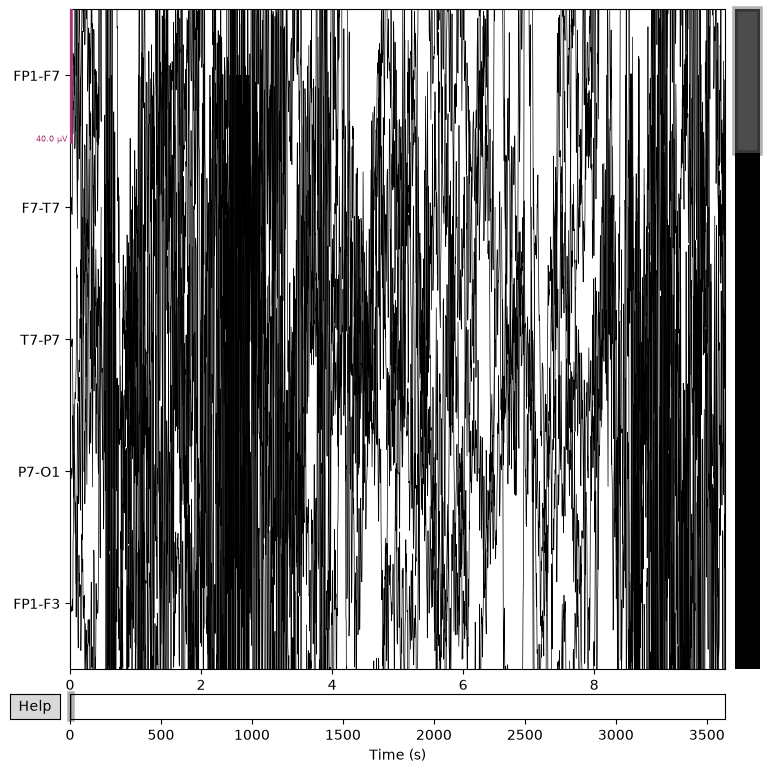

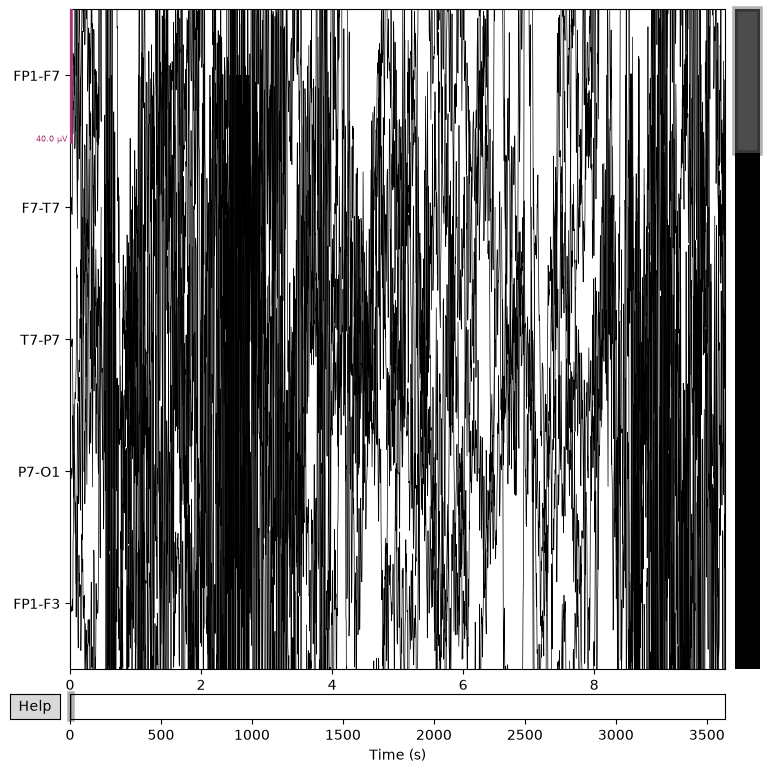

In [7]:
raw.plot(duration=10, n_channels=5)

In [8]:
data_filtrado = raw.get_data()
data_filtrado.shape

(23, 921600)

In [9]:
print("Número de canais:", data_filtrado.shape[0])
print("Número de amostras:", data_filtrado.shape[1])

Número de canais: 23
Número de amostras: 921600


In [10]:
caminhos_resumo = (Path.cwd() / "chb24-summary.txt", Path.cwd().parent / "chb24-summary.txt")
arquivo_resumo = next((caminho for caminho in caminhos_resumo if caminho.is_file()), None)
if arquivo_resumo is None:
    raise FileNotFoundError("Não foi possível localizar chb24-summary.txt na pasta do notebook ou na raiz do projeto.")

with arquivo_resumo.open("r") as f:
  conteudo = f.readlines()

for linha in conteudo[:40]:
  print(linha.strip())

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb24_01.edf
Number of Seizures in File: 2
Seizure Start Time: 480 seconds
Seizure End Time: 505 seconds
Seizure Start Time: 2451 seconds
Seizure End Time: 2476 seconds

File Name: chb24_03.edf
Number of Seizures in File: 2
Seizure Start Time: 231 seconds
Seizure End Time: 260 seconds


In [11]:
seizure_intervals_sec = [
    (480, 505),
    (2451, 2476)
]

sfreq = raw.info["sfreq"]

Intervalos pra saber quando a crise acontece e o sfreq usado pra transformar o tempo em indice

In [12]:
canal_idx = 0
signal = data_filtrado[canal_idx]

In [13]:
time = np.arange(len(signal)) / sfreq

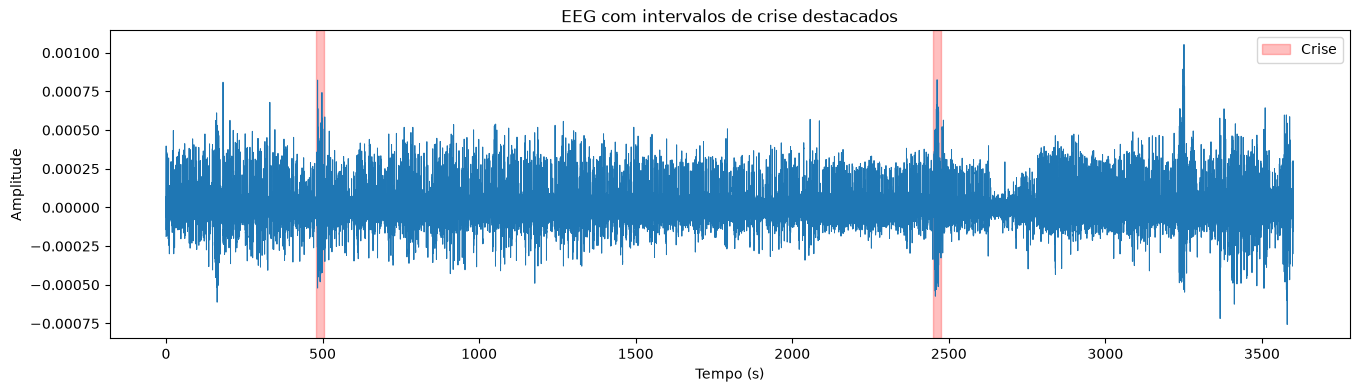

In [14]:
plt.figure(figsize=(16,4))
plt.plot(time, signal, linewidth=0.7)

for i, (start, end) in enumerate(seizure_intervals_sec):
  plt.axvspan(start, end, color="red", alpha=0.25,
              label="Crise" if i==0 else None)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG com intervalos de crise destacados")
plt.legend()
plt.show()

In [15]:
window_size = 256
step = 128

windows = []

for start in range(0, data_filtrado.shape[1] - window_size, step):
  segment = data_filtrado[:, start:start + window_size]
  windows.append(segment)

windows = np.array(windows)
windows.shape

(7198, 23, 256)

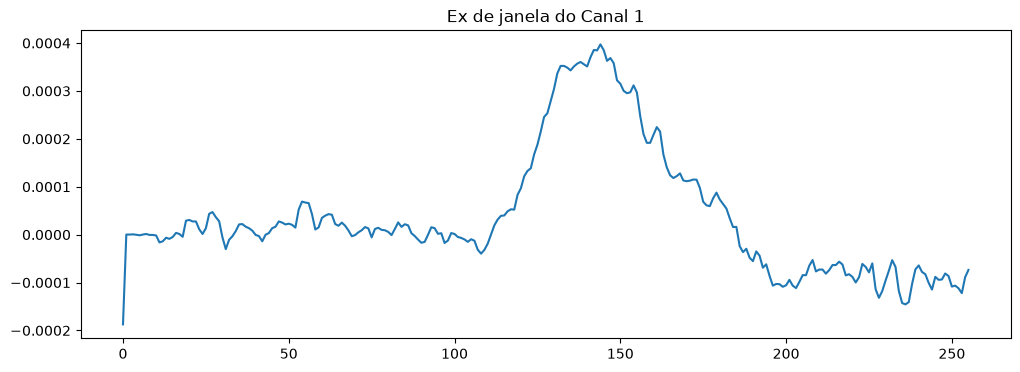

In [16]:
plt.figure(figsize=(12,4))
plt.plot(windows[0][0])
plt.title("Ex de janela do Canal 1")
plt.show()

In [17]:
print("Quantidade de janelas:", windows.shape[0])
print("Canais por janela:", windows.shape[1])
print("Pontos por janela:", windows.shape[2])

Quantidade de janelas: 7198
Canais por janela: 23
Pontos por janela: 256


In [18]:
features = []

for window in windows:
  feat = []
  feat.extend(window.mean(axis=1))
  feat.extend(window.std(axis=1))
  feat.extend(window.min(axis=1))
  feat.extend(window.max(axis=1))
  features.append(feat)

X = np.array(features)
X.shape

(7198, 92)

In [19]:
# lista onde vamos guarda o rótulo de cada janela
labels = []

# percorre o sinal da mesma forma que criamos as janelas
for start in range(0, data_filtrado.shape[1] - window_size, step):
    end = start + window_size # fim da janela

    # converte indice -> tempo (segundos)
    start_sec = start / sfreq
    end_sec = end / sfreq

    label = 0 # assume que é normal

    # verifica se a janela encosta em algum intervalo de crise
    for seizure_start, seizure_end in seizure_intervals_sec:
        overlap = (start_sec < seizure_end) and (end_sec > seizure_start)

        if overlap:
            label = 1 # marca como crise
            break

    labels.append(label) # salva o rótulo da janela

# transforma em array e exibe o resumo uma única vez
y = np.array(labels)
print("Janelas totais:", len(y))
print("Janelas com crise:", y.sum())
print("Janelas normais:", (y == 0).sum())

Janelas totais: 7198
Janelas com crise: 102
Janelas normais: 7096


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [22]:
from sklearn.metrics import accuracy_score

# o modelo faz previsões em dados que ele nunca viu (teste)
y_pred = modelo_arvore.predict(X_test)

# comparando algumas previsões com o valor real
print("Comparação entre valor real e previsto:")
for i in range(10):
    print(f"Real: {y_test[i]} | Previsto: {y_pred[i]}")
        
# calculando a acurácia (quantos ele acertou no total)
acc = accuracy_score(y_test, y_pred)

print("\nAcurácia do modelo:", acc)

Comparação entre valor real e previsto:
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0

Acurácia do modelo: 0.9888888888888889


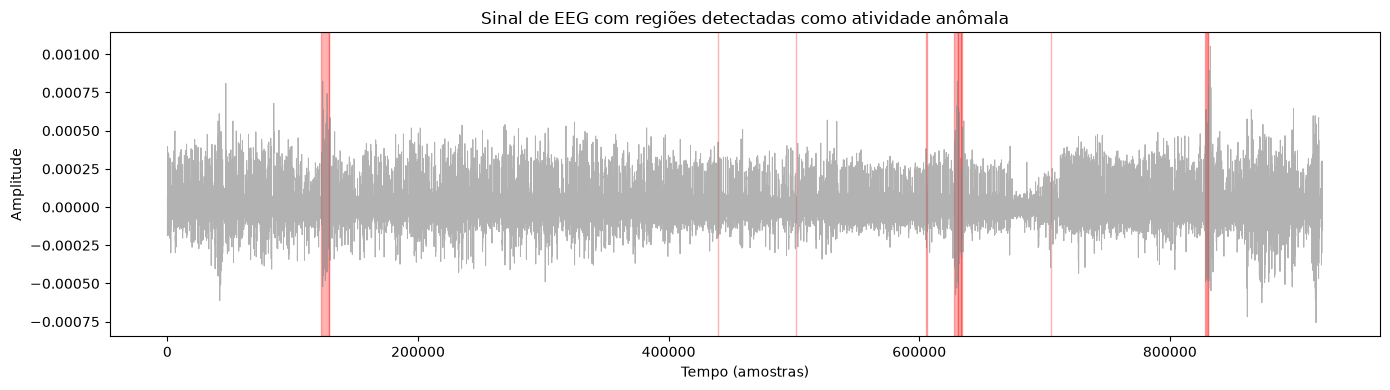

In [23]:
import matplotlib.pyplot as plt

# Para visualizar o sinal inteiro, as previsões precisam seguir a ordem de X.
# y_pred contém apenas as previsões do subconjunto X_test.
y_pred_all = modelo_arvore.predict(X)
signal = data_filtrado[0]

# Une janelas anômalas consecutivas em uma única região para reduzir o custo
# de renderização e evitar centenas de faixas sobrepostas.
anomalous_windows = np.flatnonzero(y_pred_all == 1)
anomalous_regions = []

if anomalous_windows.size:
    region_start = region_end = anomalous_windows[0]
    for window_idx in anomalous_windows[1:]:
        if window_idx <= region_end + 1:
            region_end = window_idx
        else:
            anomalous_regions.append((region_start, region_end))
            region_start = region_end = window_idx
    anomalous_regions.append((region_start, region_end))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(signal, color="gray", alpha=0.6, linewidth=0.7)

for start_window, end_window in anomalous_regions:
    start = start_window * step
    end = end_window * step + window_size
    ax.axvspan(start, end, color="red", alpha=0.3)

ax.set_title("Sinal de EEG com regiões detectadas como atividade anômala")
ax.set_xlabel("Tempo (amostras)")
ax.set_ylabel("Amplitude")
fig.tight_layout()
plt.show()
plt.close(fig)

In [24]:
amostra = X_test[0].reshape(1, -1)
pred = modelo_arvore.predict(amostra)[0]
print("Predição da amostra:", pred)


Predição da amostra: 0


In [25]:
from sklearn.neural_network import MLPClassifier

modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=300,
    random_state=42
)

modelo_mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [27]:
y_pred_mlp = modelo_mlp.predict(X_test)

print("Comparação entre valor real e previsto (Rede Neural)")
for i in range(10):
    print(f"Real: {y_test[i]} | Previsto: {y_pred_mlp[i]}")

acc_mlp = accuracy_score(y_test, y_pred_mlp)

print("\nAcurácia da rede neural:", acc_mlp)

Comparação entre valor real e previsto (Rede Neural)
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0

Acurácia da rede neural: 0.9847222222222223


In [28]:
print("Árvore de decisão:", acc)
print("Rede neural:", acc_mlp)

Árvore de decisão: 0.9888888888888889
Rede neural: 0.9847222222222223


In [30]:
X_d1 = windows.transpose(0, 2, 1) # amostras, tempo, canais
X_d1.shape

(7198, 256, 23)